In [116]:
# Uncomment the line below if running for the first time:
!pip install pandas numpy statsmodels scikit-learn plotly fredapi matplotlib seaborn

import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, LogisticRegression
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

print("Setup complete ✓")

Setup complete ✓


In [117]:
try:
    import fredapi
    FRED_API_KEY = 'YOUR_FRED_API_KEY'  # <-- Replace this
    fred = fredapi.Fred(api_key='2d24c2f966001668a1fa3df1861a5787')

    spread_raw = fred.get_series('T10Y3M', observation_start='1970-01-01')
    recession_raw = fred.get_series('USREC', observation_start='1970-01-01')

    print("FRED data loaded ✓")
    USE_FRED = True

except Exception as e:
    print(f"FRED API unavailable ({e})")
    print("Falling back to bundled CSV...")
    USE_FRED = False
    # Fallback: load from CSV included in the repo
    # df_fallback = pd.read_csv('data/fallback_yield_curve.csv', index_col=0, parse_dates=True)
    # Uncomment the line above and comment out the FRED block if the API is unavailable during class

FRED data loaded ✓


In [118]:
if USE_FRED:
    # Combine into monthly dataframe 
    spread_monthly = spread_raw.resample('ME').last()   # last trading day of each month
    recession_monthly = recession_raw.resample('ME').max()  # 1 if any day in month is recession

    df = pd.DataFrame({
        'yield_spread': spread_monthly,
        'recession': recession_monthly
    }).dropna()

    # Lag the yield spread by 12 months
    # This matches the NY Fed model: we predict recession risk 12 months ahead
    df['yield_spread_lag12'] = df['yield_spread'].shift(12)
    df = df.dropna()  # Drop first 12 months (no lag available)

# Preview the data
print(f"Dataset: {df.index[0].strftime('%Y-%m')} to {df.index[-1].strftime('%Y-%m')}")
print(f"Observations: {len(df)}")
print(f"Recession months: {df['recession'].sum()} ({df['recession'].mean():.1%} of sample)")
print(f"\nYield spread (lagged 12m) summary:")
print(df['yield_spread_lag12'].describe().round(3))
df.tail()

Dataset: 1983-01 to 2026-03
Observations: 519
Recession months: 36.0 (6.9% of sample)

Yield spread (lagged 12m) summary:
count    519.000
mean       1.563
std        1.250
min       -1.880
25%        0.630
50%        1.610
75%        2.535
max        4.090
Name: yield_spread_lag12, dtype: float64


,yield_spread,recession,yield_spread_lag12
2025-11-30,0.14,0.0,-0.40
2025-12-31,0.51,0.0,0.21
2026-01-31,0.59,0.0,0.27
2026-02-28,0.30,0.0,-0.08
2026-03-31,0.60,0.0,-0.09


In [119]:
# Prepare features and outcome
X = df[['yield_spread_lag12']].values  # Feature matrix (N x 1)
y = df['recession'].values              # Binary outcome vector

# Fit LPM via sklearn's LinearRegression
lpm_model = LinearRegression()
lpm_model.fit(X, y)

# Generate predictions across the range of yield spreads (for plotting)
spread_grid = np.linspace(df['yield_spread_lag12'].min() - 0.2,
                           df['yield_spread_lag12'].max() + 0.2, 500).reshape(-1, 1)
lpm_preds = lpm_model.predict(spread_grid)

# Count out-of-bounds predictions in the actual data
lpm_fitted = lpm_model.predict(X)
n_below_zero = (lpm_fitted < 0).sum()
n_above_one  = (lpm_fitted > 1).sum()

print(f"LPM fitted — Intercept: {lpm_model.intercept_:.4f}, Slope: {lpm_model.coef_[0]:.4f}")
print(f"\nOut-of-bounds predictions:")
print(f"  Predicted probability < 0: {n_below_zero} observations ({n_below_zero/len(df):.1%})")
print(f"  Predicted probability > 1: {n_above_one} observations ({n_above_one/len(df):.1%})")

LPM fitted — Intercept: 0.1501, Slope: -0.0516

Out-of-bounds predictions:
  Predicted probability < 0: 84 observations (16.2%)
  Predicted probability > 1: 0 observations (0.0%)


In [120]:
logit_model = LogisticRegression(random_state=42)
logit_model.fit(X, y)

# Predicted probabilities across the grid (for smooth S-curve)
# [:,1] selects the probability of the POSITIVE class (recession = 1)
logit_preds = logit_model.predict_proba(spread_grid)[:, 1]

# Also compute for the actual data points
logit_fitted = logit_model.predict_proba(X)[:, 1]

print(f"Logistic regression fitted ✓")
print(f"Intercept (β₀): {logit_model.intercept_[0]:.4f}")
print(f"Slope (β₁):     {logit_model.coef_[0][0]:.4f}")
print(f"\nOdds ratio (exp(β₁)): {np.exp(logit_model.coef_[0][0]):.4f}")
print(f"\nMin predicted probability: {logit_fitted.min():.4f}")
print(f"Max predicted probability: {logit_fitted.max():.4f}")
print(f"→ Logistic regression is always bounded in [0, 1] ✓")

Logistic regression fitted ✓
Intercept (β₀): -1.7777
Slope (β₁):     -0.7896

Odds ratio (exp(β₁)): 0.4540

Min predicted probability: 0.0066
Max predicted probability: 0.4272
→ Logistic regression is always bounded in [0, 1] ✓


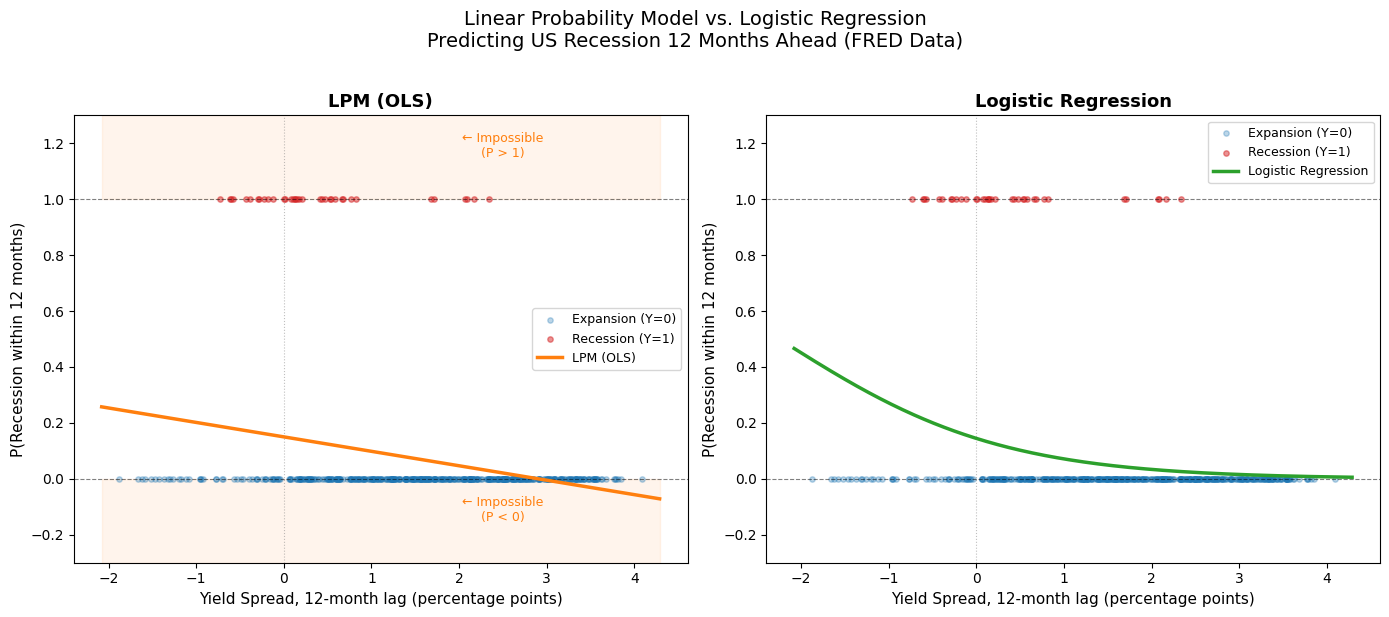

Figure saved as lpm_vs_logistic.png


In [121]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

# Colors
COLOR_RECESSION = '#d62728'   # Red for recession months
COLOR_EXPANSION = '#1f77b4'   # Blue for expansion months
COLOR_LPM = '#ff7f0e'         # Orange for LPM line
COLOR_LOGIT = '#2ca02c'       # Green for logistic line

# Separate recession and expansion observations
x_vals = df['yield_spread_lag12'].values
recession_mask = y == 1

for ax, model_preds, model_name, color in [
    (axes[0], lpm_preds,   'LPM (OLS)',           COLOR_LPM),
    (axes[1], logit_preds, 'Logistic Regression', COLOR_LOGIT)
]:
    # Scatter: actual data points
    ax.scatter(x_vals[~recession_mask], y[~recession_mask],
               color=COLOR_EXPANSION, alpha=0.3, s=15, label='Expansion (Y=0)', zorder=2)
    ax.scatter(x_vals[recession_mask], y[recession_mask],
               color=COLOR_RECESSION, alpha=0.5, s=15, label='Recession (Y=1)', zorder=2)

    # Model prediction curve
    ax.plot(spread_grid.ravel(), model_preds, color=color, lw=2.5,
            label=model_name, zorder=3)

    # Reference lines
    ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)
    ax.axhline(1, color='black', lw=0.8, linestyle='--', alpha=0.5)
    ax.axvline(0, color='gray', lw=0.8, linestyle=':', alpha=0.5)

    ax.set_xlabel('Yield Spread, 12-month lag (percentage points)', fontsize=11)
    ax.set_ylabel('P(Recession within 12 months)', fontsize=11)
    ax.set_title(model_name, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(-0.3, 1.3)

# Annotate the out-of-bounds problem on LPM panel
axes[0].fill_between(spread_grid.ravel(), -0.3, 0,
                      color=COLOR_LPM, alpha=0.08, label='Impossible region')
axes[0].fill_between(spread_grid.ravel(), 1, 1.3,
                      color=COLOR_LPM, alpha=0.08)
axes[0].text(2.5, -0.15, '← Impossible\n(P < 0)', fontsize=9, color=COLOR_LPM, ha='center')
axes[0].text(2.5,  1.15, '← Impossible\n(P > 1)', fontsize=9, color=COLOR_LPM, ha='center')

fig.suptitle('Linear Probability Model vs. Logistic Regression\nPredicting US Recession 12 Months Ahead (FRED Data)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('lpm_vs_logistic.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as lpm_vs_logistic.png")

In [122]:
# Extract the coefficient (slope on yield_spread_lag12)
beta_1 = logit_model.coef_[0][0]

odds_ratio = np.exp(beta_1)

X_sm = sm.add_constant(df[['yield_spread_lag12']])  # statsmodels needs intercept added explicitly
logit_sm = sm.Logit(df['recession'], X_sm).fit(disp=False)  # disp=False suppresses iteration output

# Extract coefficient, SE, and 95% CI from the statsmodels result
coef_table = logit_sm.summary2().tables[1]
print("Statsmodels Logit summary:")
print(coef_table)

row = coef_table.loc['yield_spread_lag12']
or_point = np.exp(row["Coef."])
or_lower = np.exp(row["[0.025"])
or_upper = np.exp(row["0.975]"])

print(f"\n{'='*50}")
print(f"Odds Ratio: {or_point:.4f}")
print(f"95% CI:     [{or_lower:.4f}, {or_upper:.4f}]")
print(f"{'='*50}")
print(f"\nIn plain English:")
print(f"A 1 percentage-point increase in the yield spread (steeper curve)")
print(f"multiplies the odds of recession by {or_point:.3f}.")
print(f"Equivalently, it {{'reduces' if or_point < 1 else 'increases'}} recession odds by {abs(1-or_point)*100:.1f}%.")

Statsmodels Logit summary:
                       Coef.  Std.Err.         z         P>|z|    [0.025  \
const              -1.766832  0.197916 -8.927162  4.370766e-19 -2.154741   
yield_spread_lag12 -0.807730  0.150892 -5.353036  8.649080e-08 -1.103473   

                      0.975]  
const              -1.378923  
yield_spread_lag12 -0.511987  

Odds Ratio: 0.4459
95% CI:     [0.3317, 0.5993]

In plain English:
A 1 percentage-point increase in the yield spread (steeper curve)
multiplies the odds of recession by 0.446.
Equivalently, it {'reduces' if or_point < 1 else 'increases'} recession odds by 55.4%.


In [123]:
df['recession_prob'] = logit_model.predict_proba(X)[:,1]

# Verify: probabilities should be between 0 and 1
print(f"Min probability: {df['recession_prob'].min():.4f}")
print(f"Max probability: {df['recession_prob'].max():.4f}")
print(f"Mean probability: {df['recession_prob'].mean():.4f}")
print(f"Base rate (actual recession %): {df['recession'].mean():.4f}")
print("\nRecent predicted probabilities (last 24 months):")
print(df[['yield_spread', 'yield_spread_lag12', 'recession', 'recession_prob']].tail(24).round(4))

Min probability: 0.0066
Max probability: 0.4272
Mean probability: 0.0693
Base rate (actual recession %): 0.0694

Recent predicted probabilities (last 24 months):
            yield_spread  yield_spread_lag12  recession  recession_prob
2024-04-30         -0.77               -1.66        0.0          0.3853
2024-05-31         -0.95               -1.88        0.0          0.4272
2024-06-30         -1.12               -1.62        0.0          0.3779
2024-07-31         -1.32               -1.58        0.0          0.3705
2024-08-31         -1.30               -1.47        0.0          0.3505
2024-09-30         -0.92               -0.96        0.0          0.2651
2024-10-31         -0.36               -0.71        0.0          0.2284
2024-11-30         -0.40               -1.08        0.0          0.2839
2024-12-31          0.21               -1.52        0.0          0.3595
2025-01-31          0.27               -1.43        0.0          0.3433
2025-02-28         -0.08               -1.20  

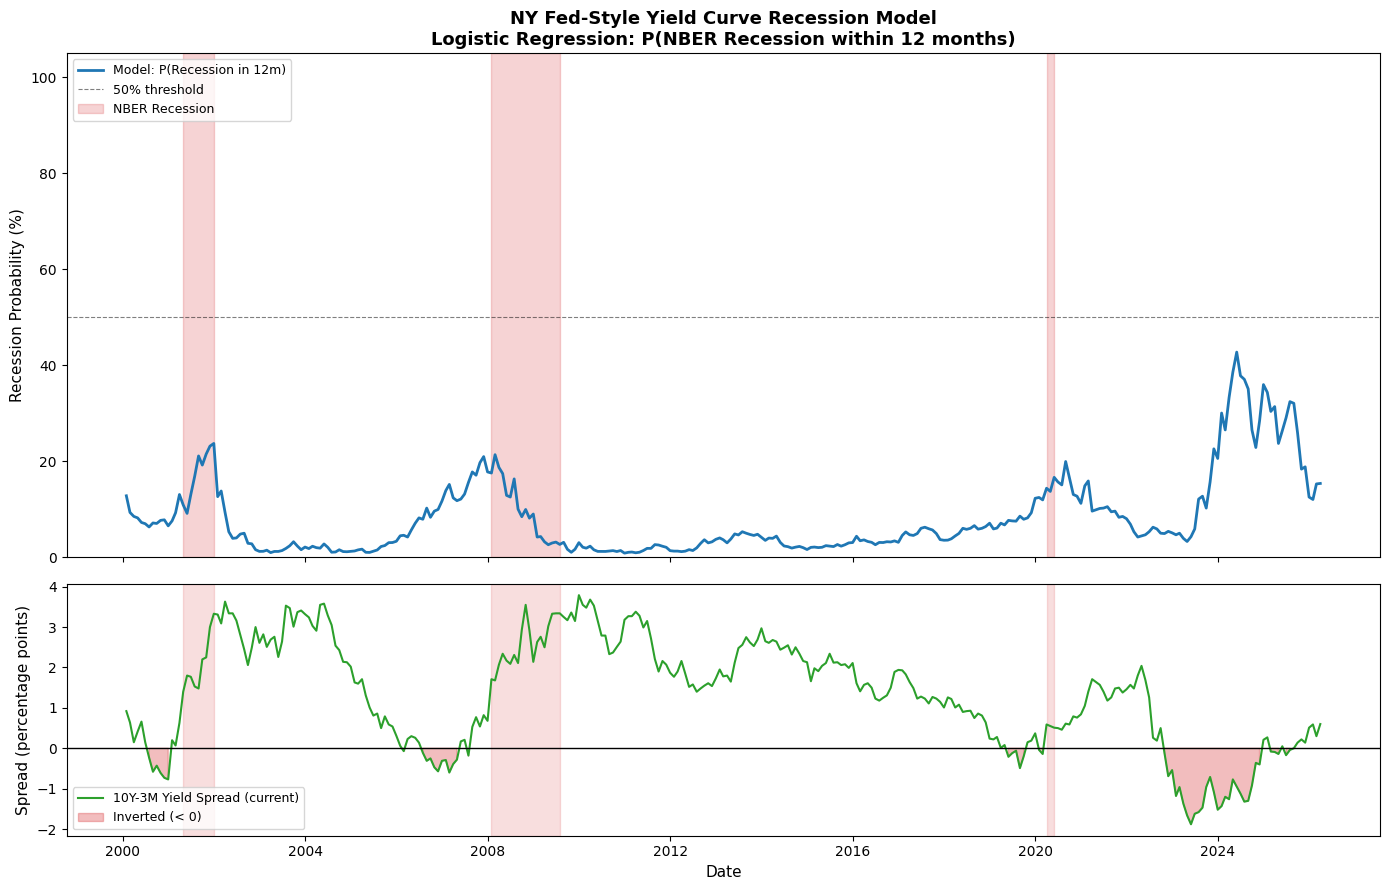

Figure saved as recession_probability_series.png


In [124]:
df_plot = df['2000':].copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                                 gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(df_plot.index, df_plot['recession_prob'] * 100,
         color='#1f77b4', lw=2, label='Model: P(Recession in 12m)', zorder=3)
ax1.axhline(50, color='black', lw=0.8, linestyle='--', alpha=0.5, label='50% threshold')

def get_recession_bands(df_in):
    """Return list of (start_date, end_date) tuples for NBER recession periods."""
    in_recession = False
    bands = []
    start = None
    for date, val in df_in['recession'].items():
        if val == 1 and not in_recession:
            start = date
            in_recession = True
        elif val == 0 and in_recession:
            bands.append((start, date))
            in_recession = False
    if in_recession:  # Handle case where sample ends in recession
        bands.append((start, df_in.index[-1]))
    return bands

recession_bands = get_recession_bands(df_plot)
for i, (start, end) in enumerate(recession_bands):
    ax1.axvspan(start, end, color="#d62728", alpha=0.2, label="NBER Recession" if i==0 else None)
    pass

ax1.set_ylabel('Recession Probability (%)', fontsize=11)
ax1.set_ylim(0, 105)
ax1.legend(fontsize=9, loc='upper left')
ax1.set_title('NY Fed-Style Yield Curve Recession Model\nLogistic Regression: P(NBER Recession within 12 months)',
              fontsize=13, fontweight='bold')

ax2.plot(df_plot.index, df_plot['yield_spread'],
         color='#2ca02c', lw=1.5, label='10Y-3M Yield Spread (current)')
ax2.axhline(0, color='black', lw=1, linestyle='-')
ax2.fill_between(df_plot.index, df_plot['yield_spread'], 0,
                  where=(df_plot['yield_spread'] < 0),
                  color='#d62728', alpha=0.3, label='Inverted (< 0)')
for start, end in recession_bands:
    ax2.axvspan(start, end, color='#d62728', alpha=0.15)

ax2.set_ylabel('Spread (percentage points)', fontsize=11)
ax2.set_xlabel('Date', fontsize=11)
ax2.legend(fontsize=9, loc='lower left')

plt.tight_layout()
plt.savefig('recession_probability_series.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as recession_probability_series.png")

In [125]:
# The predicted recession probability was 42.7%

# The model isn't wrong, it was able to signal the risk, but not the certainty. Having a 43% chance of happening would mean 57% chance of not happening

# For the 2006-2007 model, the yield curve inverted deeply which caused the model's predicted recession to spike. The model performed well compared to 2008-2009 model.

In [126]:
import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from fredapi import Fred
from sklearn.linear_model import LogisticRegression

# --- Streamlit Page Config ---
st.set_page_config(page_title="Recession Probability Dashboard", layout="wide")
st.title("US Recession Probability Forecasting Model")

# --- Sidebar Controls ---
st.sidebar.header("Model Parameters")
api_key = st.sidebar.text_input("Enter FRED API Key:", type="password")
lag_months = st.sidebar.slider("Select Forecast Horizon (Lag in Months)", min_value=6, max_value=18, value=12, step=6)

@st.cache_data(ttl=86400) # Cache data for 24 hours
def load_data(api_key):
    """Fetches and prepares the raw data from FRED."""
    fred = Fred(api_key=api_key)
    spread_raw = fred.get_series('T10Y3M', observation_start='1970-01-01')
    recession_raw = fred.get_series('USREC', observation_start='1970-01-01')
    
    # Resample to monthly
    spread_monthly = spread_raw.resample('ME').last()
    recession_monthly = recession_raw.resample('ME').max()
    
    df_raw = pd.DataFrame({
        'yield_spread': spread_monthly,
        'recession': recession_monthly
    }).dropna()
    return df_raw

if api_key:
    try:
        # Load and prep data based on selected lag
        df_base = load_data(api_key)
        df = df_base.copy()
        
        # Apply dynamic lag
        lag_col_name = f'yield_spread_lag{lag_months}'
        df[lag_col_name] = df['yield_spread'].shift(lag_months)
        df = df.dropna()
        
        # Define X and y for the model
        X = df[[lag_col_name]].values
        y = df['recession'].values
        
        # --- Model Fitting ---
        logit_model = LogisticRegression(random_state=42)
        logit_model.fit(X, y)
        df['recession_prob'] = logit_model.predict_proba(X)[:, 1]

        # --- Bootstrapping for Confidence Interval ---
        # [Mechanism Check] 
        # We use bootstrapping to estimate the uncertainty of our model's predictions.
        # Standard logistic regression output doesn't natively provide confidence bands 
        # for the *predicted probabilities* easily without relying on delta-method approximations.
        
        n_iterations = 200  # Number of bootstrap samples
        n_size = len(X)
        bootstrap_preds = np.zeros((n_iterations, n_size))
        
        for i in range(n_iterations):
            # 1. Resample with replacement: We draw a random sample of indices of the 
            #    same size as the original dataset, allowing for duplicates.
            indices = np.random.randint(0, n_size, n_size)
            X_b, y_b = X[indices], y[indices]
            
            # 2. Refit the model: We train a new logistic regression model strictly 
            #    on this new "synthetic" dataset.
            model_b = LogisticRegression()
            model_b.fit(X_b, y_b)
            
            # 3. Predict: We use this refitted model to predict probabilities on the 
            #    *original* timeline (X) so we can stack them and calculate percentiles.
            bootstrap_preds[i, :] = model_b.predict_proba(X)[:, 1]
            
        # 4. Calculate the 90% confidence interval (5th and 95th percentiles) across all iterations
        df['prob_lower_90'] = np.percentile(bootstrap_preds, 5, axis=0)
        df['prob_upper_90'] = np.percentile(bootstrap_preds, 95, axis=0)


        # --- Plotly Visualization ---
        fig = go.Figure()

        # Add 90% Confidence Band
        fig.add_trace(go.Scatter(
            x=df.index.tolist() + df.index.tolist()[::-1],
            y=df['prob_upper_90'].tolist() + df['prob_lower_90'].tolist()[::-1],
            fill='toself',
            fillcolor='rgba(31, 119, 180, 0.2)',
            line=dict(color='rgba(255,255,255,0)'),
            hoverinfo="skip",
            name='90% Confidence Band'
        ))

        # Add Main Prediction Line
        fig.add_trace(go.Scatter(
            x=df.index, 
            y=df['recession_prob'],
            mode='lines',
            line=dict(color='#1f77b4', width=2),
            name=f'P(Recession in {lag_months}m)'
        ))

        # Add 50% Threshold line
        fig.add_hline(y=0.5, line_dash="dash", line_color="black", opacity=0.5, annotation_text="50% Threshold")

        # Add NBER Recession Shading
        in_recession = False
        start_date = None
        for date, val in df['recession'].items():
            if val == 1 and not in_recession:
                start_date = date
                in_recession = True
            elif val == 0 and in_recession:
                fig.add_vrect(x0=start_date, x1=date, fillcolor="red", opacity=0.15, layer="below", line_width=0)
                in_recession = False
        if in_recession: # Handle if currently in recession
             fig.add_vrect(x0=start_date, x1=df.index[-1], fillcolor="red", opacity=0.15, layer="below", line_width=0)

        fig.update_layout(
            title=f"Probability of US Recession {lag_months} Months Ahead",
            yaxis_title="Probability",
            yaxis=dict(range=[0, 1], tickformat='.0%'),
            xaxis_title="Date",
            hovermode="x unified",
            legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
        )
        st.plotly_chart(fig, use_container_width=True)

        # --- Sidebar Real-Time Metrics ---
        latest_date = df.index[-1].strftime('%B %Y')
        latest_spread = df_base['yield_spread'].iloc[-1]
        latest_prob = df['recession_prob'].iloc[-1]
        
        st.sidebar.divider()
        st.sidebar.subheader("Current Snapshot")
        st.sidebar.write(f"**As of:** {latest_date}")
        st.sidebar.metric(label="Current 10Y-3M Spread", value=f"{latest_spread:.2f} pts")
        st.sidebar.metric(label=f"Predicted Probability ({lag_months}m ahead)", value=f"{latest_prob:.1%}")

    except Exception as e:
        st.error(f"Error fetching or processing data. Please check your API key. Details: {e}")
else:
    st.info("Please enter your FRED API key in the sidebar to load the dashboard.")

2026-04-13 02:32:07.422 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-13 02:32:07.422 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-13 02:32:07.444 
  command:

    streamlit run /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-04-13 02:32:07.444 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-13 02:32:07.444 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-13 02:32:07.445 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-13 02:32:07.445 Thread 'MainThread': missing ScriptRunContext! 